<a href="https://colab.research.google.com/github/Clover130/u8229609-Individual-Project/blob/main/EMSC2010_Individual_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Individual Project: Groundwater Modelling in the Murray Darling Basin

## Research Question
"Which climatic factor — rainfall, temperature, or evapotranspiration — is the most significant predictor of groundwater level fluctuations, and can a simple water balance model reproduce observed storage changes?" REFINE

Is groundwater storage level directly correlated to precipitation inflow?

Hypothesis: there will be correlation, however this doesn't consider the extraction for industry


groundwater levels alongside rainfall, temperature, and ET over time

## Context/Background Information

## Datasets

https://www.bom.gov.au/water/groundwater/explorer/map.shtml

https://longpaddock.qld.gov.au/silo/point-data/#responseTab2

Data Categories:
- Groundwater: Reduced Standing Water Level (RSWL, in mAHD) — the water level expressed as an elevation above the Australian Height Datum (mean sea level = 0)

- FAO56 (from the UN Food and Agriculture Organisation Irrigation Paper 56) estimates reference evapotranspiration (ET₀) — essentially how much water a standardised short grass surface would lose given the local climate conditions. It combines temperature, humidity, wind, and solar radiation into one variable
  - international standard in hydrology and groundwater studies
  - atmospheric demand for water (drives water loss in soil and transpiration --> major cause of reduction in soil moisture --> less recharge)
  - estimates potential ET under reference conditions (actual ET may be lower under drought scenarios)
- Max Temp

**FAIR Principles**

## Method/Analysis

- find datasets for a specific location in the Murray Darling basin
## Course Connection

## AI Use


# Data Import

### Load Data Files

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

Groundwater Data File

In [2]:
# Load groundwater data
gw_raw = pd.read_excel('groundwater_data_GW030170.1.1.xlsx',
                       sheet_name = 'Water Level (GW0301701.1)',
                       parse_dates=['Date'])

print("Columns:", gw_raw.columns.tolist())
print("Date dtype:", gw_raw['Date'].dtype)       # should say datetime64
print("Variables present:", gw_raw['Variable'].unique())  # should show DTW, RSWL, SWL
print(gw_raw.head(10))

# Load climate data
climate_raw = pd.read_csv('Wee_Waa_climate_data.csv', parse_dates=['YYYY-MM-DD'])
print("Columns:", climate_raw.columns.tolist())
print("Date dtype:", climate_raw['YYYY-MM-DD'].dtype)       # should say datetime64
print(climate_raw.head(10))

Columns: ['Bore ID', 'Date', 'Variable', 'Result (m)', 'Quality Code', 'Agency']
Date dtype: datetime64[ns]
Variables present: ['DTW' 'RSWL (mAHD)' 'SWL']
        Bore ID       Date     Variable  Result (m) Quality Code    Agency
0  GW030170.1.1 1972-01-24          DTW        8.33    quality-E  WaterNSW
1  GW030170.1.1 1972-01-24  RSWL (mAHD)      188.57    quality-E  WaterNSW
2  GW030170.1.1 1972-01-24          SWL        9.13    quality-E  WaterNSW
3  GW030170.1.1 1972-04-13          DTW        8.69    quality-E  WaterNSW
4  GW030170.1.1 1972-04-13  RSWL (mAHD)      188.21    quality-E  WaterNSW
5  GW030170.1.1 1972-04-13          SWL        9.49    quality-E  WaterNSW
6  GW030170.1.1 1972-05-18          DTW        8.91    quality-E  WaterNSW
7  GW030170.1.1 1972-05-18  RSWL (mAHD)      187.99    quality-E  WaterNSW
8  GW030170.1.1 1972-05-18          SWL        9.71    quality-E  WaterNSW
9  GW030170.1.1 1972-07-24          DTW        9.26    quality-E  WaterNSW
Columns: ['station',

Extract Variables of Interest

In [3]:
## AI help here
# Groundwater dataset
# extract RSWL only and resample to monthly mea
# Filter to just the RSWL variable (absolute elevation, most useful for analysis)
rswl = gw_raw[gw_raw['Variable'] == 'RSWL (mAHD)'][['Date', 'Result (m)']].copy()
rswl = rswl.rename(columns={'Result (m)': 'RSWL_mAHD'})
rswl = rswl.set_index('Date').sort_index()

# Resample to monthly mean (irregular sampling and missing months)
# 'MS' = Month Start frequency
gw_monthly = rswl.resample('MS').mean()

gw_monthly['RSWL_mAHD'] = gw_monthly['RSWL_mAHD'].interpolate(method='linear')

print(gw_monthly.head())

            RSWL_mAHD
Date                 
1972-01-01     188.57
1972-02-01     188.45
1972-03-01     188.33
1972-04-01     188.21
1972-05-01     187.99


Load Climate Data File

In [4]:
# Climate dataset
# resample daily data to monthly
# Adjust column names
climate = climate_raw.rename(columns={
    'Date':       'YYYY-MM-DD',
    'Rain (mm)':  'daily_rain',
    'Max temp (°C)': 'max_temp',
    'et_short_crop': 'et_short_crop',
    'Pan Evaporation (mm)': 'evap_pan'
}).set_index('YYYY-MM-DD').sort_index()

# Rainfall and ET are totals = sum each month
# Temperature is a daily max = mean across the month makes sense
climate_monthly = climate[['daily_rain', 'et_short_crop', 'evap_pan']].resample('MS').sum()
climate_monthly['max_temp'] = climate[['max_temp']].resample('MS').mean()

Create Dataframe with all data of interest

In [5]:
# AI help
# Combine into one aligned dataframe
# Inner join: only keeps months where BOTH datasets have data
df = gw_monthly.join(climate_monthly, how='inner')

# Flag months where groundwater was missing (NaN after resample)
n_gw_missing = gw_monthly['RSWL_mAHD'].isna().sum()
print(f"Months with no groundwater reading: {n_gw_missing}")
print(f"Final dataset: {len(df)} months from {df.index.min()} to {df.index.max()}")
print(df.head())

Months with no groundwater reading: 0
Final dataset: 629 months from 1972-01-01 00:00:00 to 2024-05-01 00:00:00
            RSWL_mAHD  daily_rain  et_short_crop  evap_pan   max_temp
Date                                                                 
1972-01-01     188.57         0.8           47.5      54.3  30.962500
1972-02-01     188.45        31.5          165.3     197.8  31.268966
1972-03-01     188.33        11.9          162.4     186.7  31.448387
1972-04-01     188.21        10.7          110.7     139.2  26.403333
1972-05-01     187.99        31.8           79.7      98.4  22.900000


#Analysis - Time Series and Frequency

### Visualise the Data

Including a 12 month rolling mean to visualise changes over the course of the data

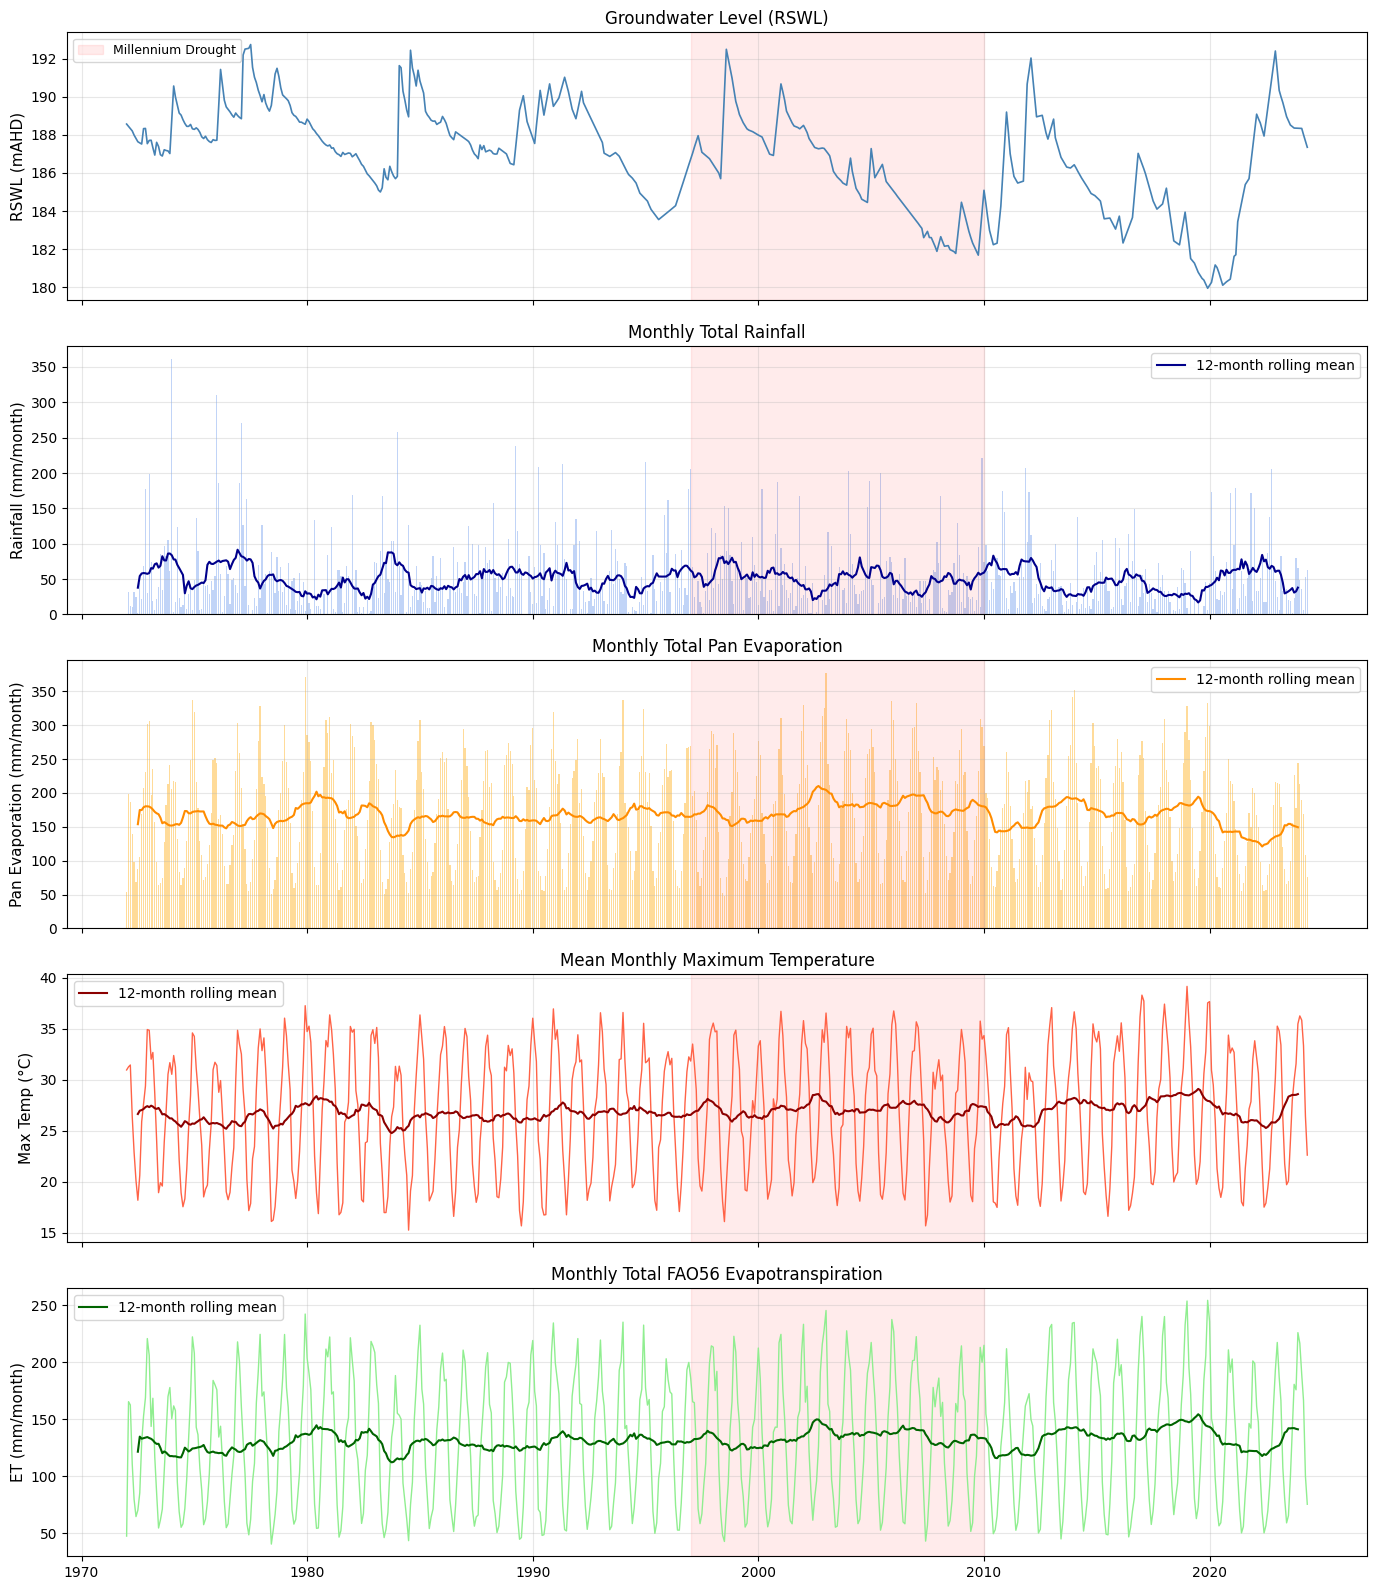

In [6]:
# Plot each variable on a timeseries axis
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)

# Shared x-axis formatting
#years = mdates.YearLocator(5)
#years_fmt = mdates.DateFormatter('%Y')

# -- Groundwater level
axes[0].plot(df.index, df['RSWL_mAHD'], color='steelblue', linewidth=1.2)
axes[0].set_ylabel('RSWL (mAHD)', fontsize=11)
axes[0].set_title('Groundwater Level (RSWL)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# -- Rainfall
df['rainfall_12m'] = df['daily_rain'].rolling(window=12, center=True).mean() ## rolling mean
axes[1].bar(df.index, df['daily_rain'], width=20, color='cornflowerblue', alpha=0.4)
axes[1].plot(df.index, df['rainfall_12m'], color='darkblue', linewidth=1.5, label='12-month rolling mean')
axes[1].legend()
axes[1].set_ylabel('Rainfall (mm/month)', fontsize=11)
axes[1].set_title('Monthly Total Rainfall', fontsize=12)
axes[1].grid(True, alpha=0.3)

# -- Pan Evaporation
df['evaporation_12m'] = df['evap_pan'].rolling(window=12, center=True).mean() ## rolling mean
axes[2].bar(df.index, df['evap_pan'], width=20, color='orange', alpha=0.4)
axes[2].plot(df.index, df['evaporation_12m'], color='darkorange', linewidth=1.5, label='12-month rolling mean')
axes[2].legend()
axes[2].set_ylabel('Pan Evaporation (mm/month)', fontsize=11)
axes[2].set_title('Monthly Total Pan Evaporation', fontsize=12)
axes[2].grid(True, alpha=0.3)

# -- Max Temperature
df['max temp_12m'] = df['max_temp'].rolling(window=12, center=True).mean() ## rolling mean
axes[3].plot(df.index, df['max_temp'], color='tomato', linewidth=1.0)
axes[3].plot(df.index, df['max temp_12m'], color='darkred', linewidth=1.5, label='12-month rolling mean')
axes[3].legend()
axes[3].set_ylabel('Max Temp (°C)', fontsize=11)
axes[3].set_title('Mean Monthly Maximum Temperature', fontsize=12)
axes[3].grid(True, alpha=0.3)

# -- Evapotranspiration
df['evaptrans_12m'] = df['et_short_crop'].rolling(window=12, center=True).mean() ## rolling mean
axes[4].plot(df.index, df['et_short_crop'], color='lightgreen', linewidth=1.0)
axes[4].plot(df.index, df['evaptrans_12m'], color='darkgreen', linewidth=1.5, label='12-month rolling mean')
axes[4].legend()
axes[4].set_ylabel('ET (mm/month)', fontsize=11)
axes[4].set_title('Monthly Total FAO56 Evapotranspiration', fontsize=12)
axes[4].grid(True, alpha=0.3)
#axes[4].xaxis.set_major_locator(years)
#axes[4].xaxis.set_major_formatter(years_fmt)

# Shade the Millennium Drought period for reference across all panels (AI help)
for ax in axes:
    ax.axvspan(pd.Timestamp('1997-01-01'), pd.Timestamp('2009-12-31'),
               alpha=0.08, color='red', label='Millennium Drought')
axes[0].legend(fontsize=9)
plt.tight_layout()
plt.show()



### Seasonal Decomposition

In [7]:
def freq_spectrum(time,signal):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT (positive freqs only)
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  # Amplitude: scale by 2/n so each peak height equals the true amplitude
  amplitude = (2 / n) * np.abs(fft_vals)
  amplitude[0] /= 2

  return freqs, amplitude

def lowpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs>cutoff] = 0.0 #cycles above the frequency cutoff are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal


def highpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs<cutoff] = 0.0 #cycles below the frequency cutoff are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal

def bandpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs<cutoff[0]] = 0.0 #cycles below cutoff[0] are given an amplitude of 0
  fft_vals[freqs>cutoff[1]] = 0.0 #cycles above cutoff[1] are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal

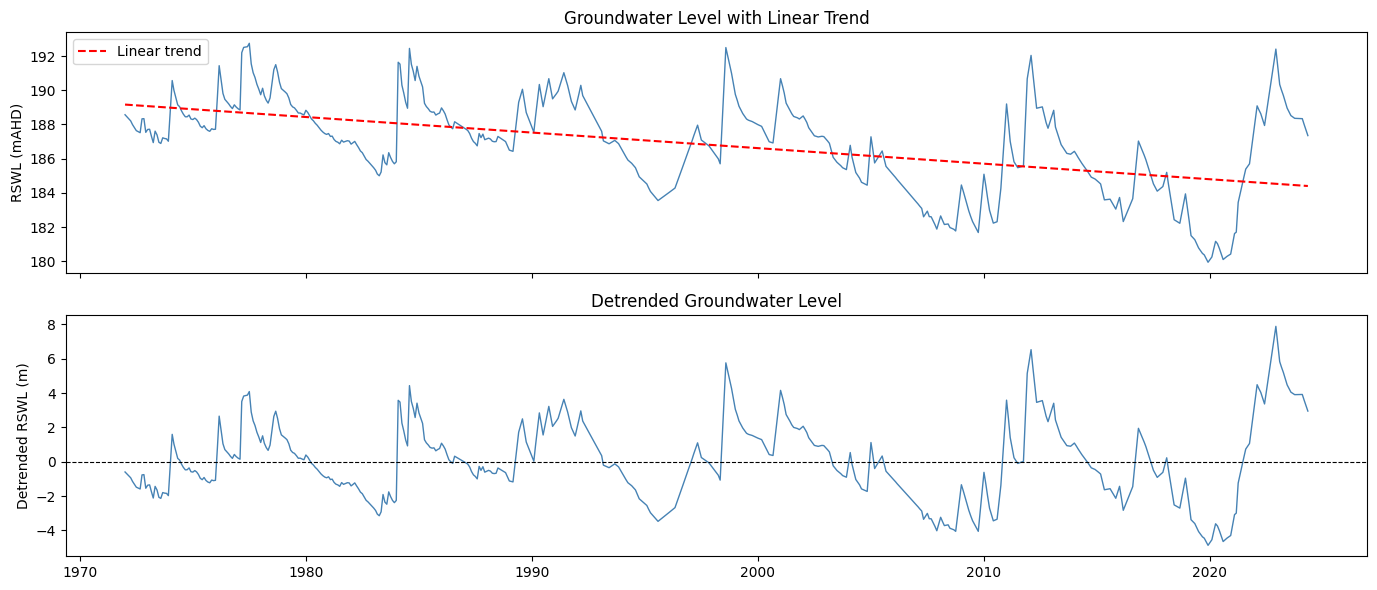

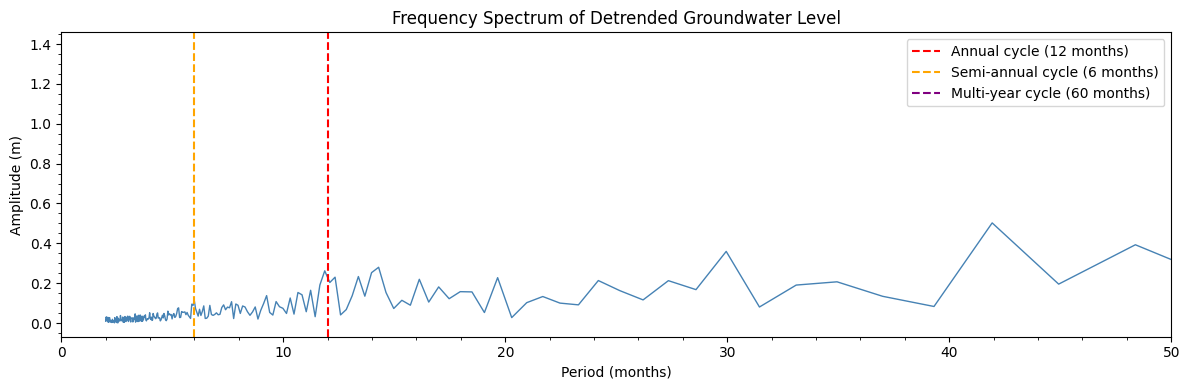

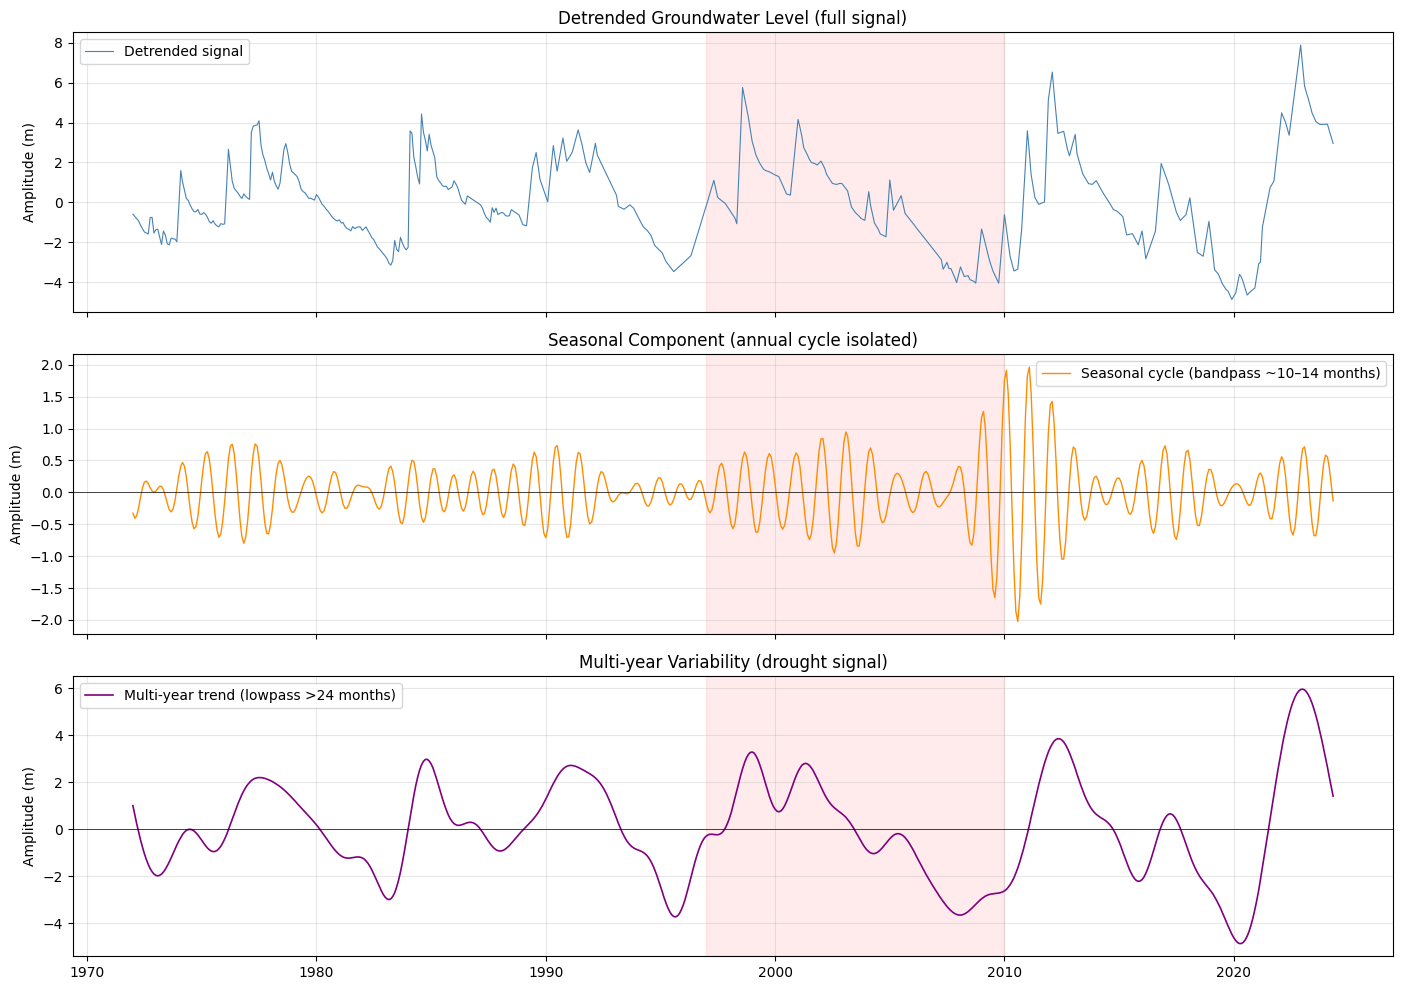

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ── SETUP ──────────────────────────────────────────────────────────────────────
# Convert datetime index to numeric time axis (months since start)
# The FFT functions need a plain numeric array, not datetime objects
time = np.arange(len(df))                  # integer month index: 0, 1, 2, ...
signal = df['RSWL_mAHD'].values            # groundwater level as numpy array

# ── STEP 1: DETREND ────────────────────────────────────────────────────────────
# Fit and remove a linear trend (analogous to the Milankovitch example)
pp = np.polyfit(time, signal, 1)           # fit degree-1 polynomial (linear trend)
trend = np.polyval(pp, time)               # evaluate the trend line
detrended = signal - trend                 # remove trend from signal

# Plot raw signal and trend to confirm detrending looks sensible
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(df.index, signal, color='steelblue', linewidth=1)
axes[0].plot(df.index, trend, color='red', linewidth=1.5, linestyle='--', label='Linear trend')
axes[0].set_ylabel('RSWL (mAHD)')
axes[0].set_title('Groundwater Level with Linear Trend')
axes[0].legend()

axes[1].plot(df.index, detrended, color='steelblue', linewidth=1)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_ylabel('Detrended RSWL (m)')
axes[1].set_title('Detrended Groundwater Level')
plt.tight_layout()
plt.show()

# ── STEP 2: FREQUENCY SPECTRUM ─────────────────────────────────────────────────
# Uses the same freq_spectrum() function from your class code
freqs, amps = freq_spectrum(time, detrended)

# Convert frequency (cycles/month) to period (months) for labelling
# Ignore the zero-frequency (DC) component at freqs[0]
periods = 1 / freqs[1:]    # period in months
amps_plot = amps[1:]        # matching amplitudes

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(periods, amps_plot, color='steelblue', linewidth=1)

# Mark physically meaningful periods for groundwater
ax.axvline(x=12,  color='red',    linestyle='--', label='Annual cycle (12 months)')
ax.axvline(x=6,   color='orange', linestyle='--', label='Semi-annual cycle (6 months)')
ax.axvline(x=60,  color='purple', linestyle='--', label='Multi-year cycle (60 months)')

ax.set_xlabel('Period (months)')
ax.set_ylabel('Amplitude (m)')
ax.set_title('Frequency Spectrum of Detrended Groundwater Level')
ax.set_xlim([0, 50])      # focus on periods up to ~17 years
ax.legend()
ax.minorticks_on()
plt.tight_layout()
plt.show()

# ── STEP 3: APPLY FILTERS ──────────────────────────────────────────────────────
# Isolate the annual seasonal cycle using a bandpass filter
# Cutoff frequencies in cycles/month: annual = 1/12, allow ± a couple months
cutoff_seasonal = [1/14, 1/10]     # bandpass around the annual cycle

x_filt, y_seasonal = bandpass_filter(time, detrended, cutoff_seasonal)

# Isolate slow multi-year variability (e.g. drought cycles) using a lowpass filter
cutoff_lowpass = 1/24              # only keep cycles longer than 2 years

x_filt, y_lowpass = lowpass_filter(time, detrended, cutoff_lowpass)

# Plot detrended signal with both filtered components overlaid
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, detrended, color='steelblue', linewidth=0.8, label='Detrended signal')
axes[0].set_ylabel('Amplitude (m)')
axes[0].set_title('Detrended Groundwater Level (full signal)')
axes[0].legend()

axes[1].plot(df.index, y_seasonal, color='darkorange', linewidth=1, label='Seasonal cycle (bandpass ~10–14 months)')
axes[1].set_ylabel('Amplitude (m)')
axes[1].set_title('Seasonal Component (annual cycle isolated)')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].legend()

axes[2].plot(df.index, y_lowpass, color='purple', linewidth=1.2, label='Multi-year trend (lowpass >24 months)')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_ylabel('Amplitude (m)')
axes[2].set_title('Multi-year Variability (drought signal)')
axes[2].legend()

# Shade Millennium Drought on all panels
for ax in axes:
    ax.axvspan(pd.Timestamp('1997-01-01'), pd.Timestamp('2009-12-31'),
               alpha=0.08, color='red', label='Millennium Drought')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

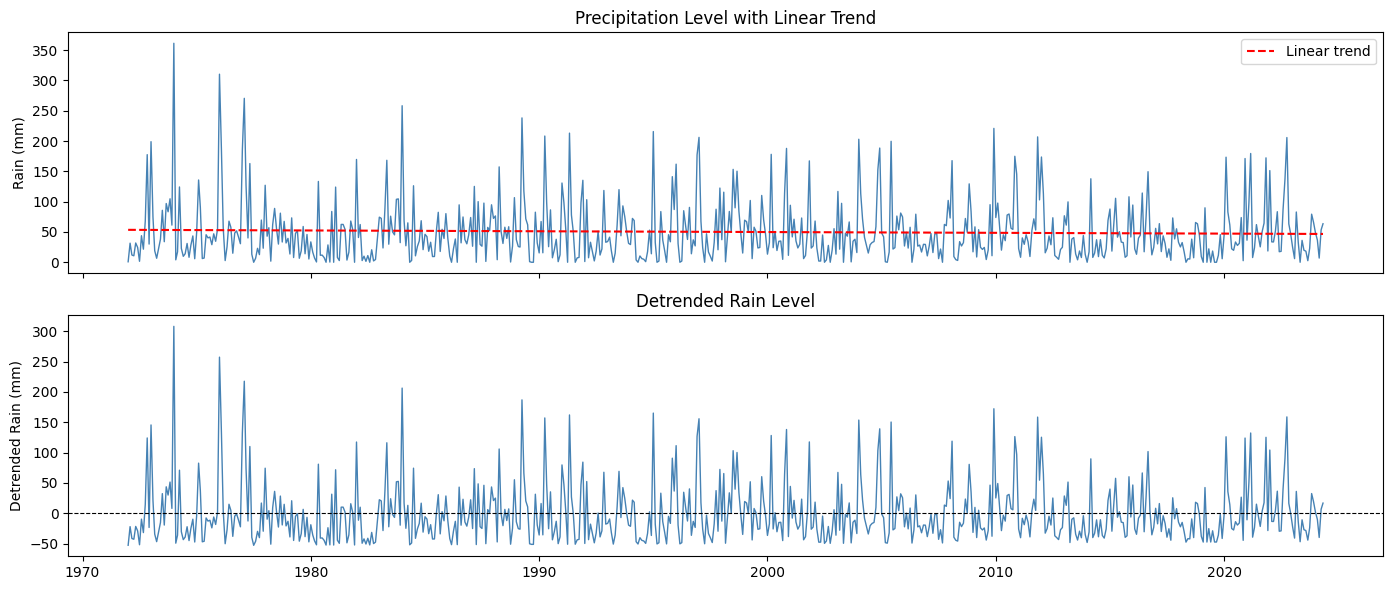

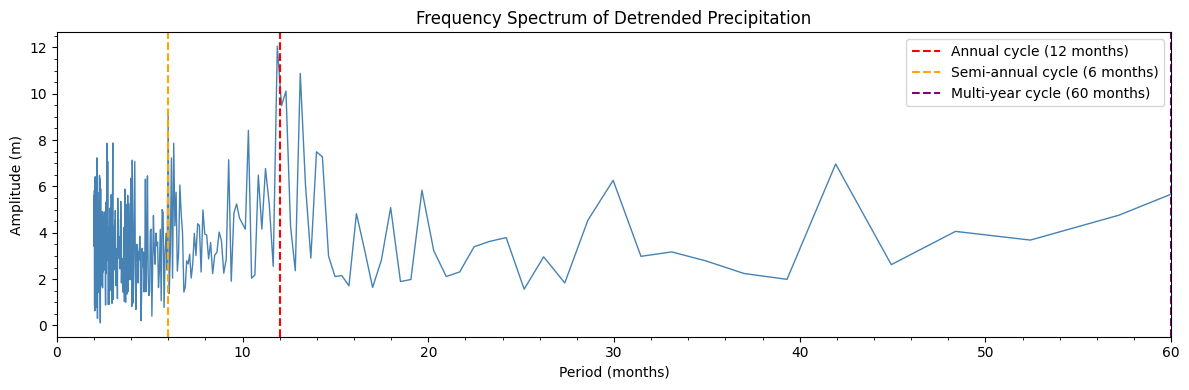

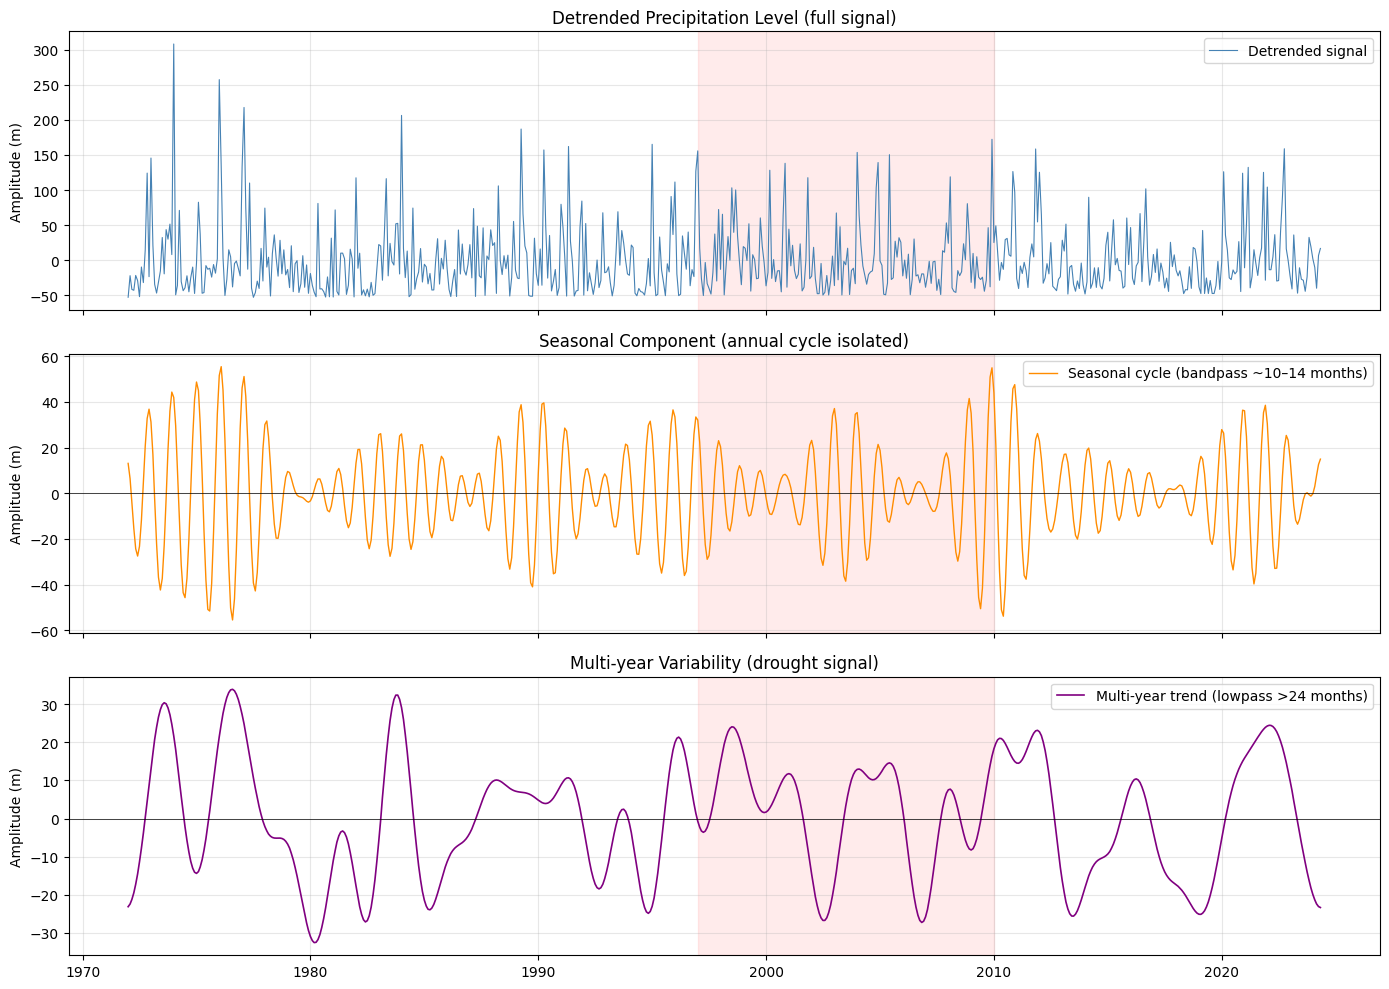

In [9]:

# ── SETUP ──────────────────────────────────────────────────────────────────────
# Convert datetime index to numeric time axis (months since start)
# The FFT functions need a plain numeric array, not datetime objects
time = np.arange(len(df))                  # integer month index: 0, 1, 2, ...
signal = df['daily_rain'].values            # groundwater level as numpy array

# ── STEP 1: DETREND ────────────────────────────────────────────────────────────
# Fit and remove a linear trend (analogous to the Milankovitch example)
pp = np.polyfit(time, signal, 1)           # fit degree-1 polynomial (linear trend)
trend = np.polyval(pp, time)               # evaluate the trend line
detrended = signal - trend                 # remove trend from signal

# Plot raw signal and trend to confirm detrending looks sensible
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(df.index, signal, color='steelblue', linewidth=1)
axes[0].plot(df.index, trend, color='red', linewidth=1.5, linestyle='--', label='Linear trend')
axes[0].set_ylabel('Rain (mm)')
axes[0].set_title('Precipitation Level with Linear Trend')
axes[0].legend()

axes[1].plot(df.index, detrended, color='steelblue', linewidth=1)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_ylabel('Detrended Rain (mm)')
axes[1].set_title('Detrended Rain Level')
plt.tight_layout()
plt.show()

# ── STEP 2: FREQUENCY SPECTRUM ─────────────────────────────────────────────────
# Uses the same freq_spectrum() function from your class code
freqs, amps = freq_spectrum(time, detrended)

# Convert frequency (cycles/month) to period (months) for labelling
# Ignore the zero-frequency (DC) component at freqs[0]
periods = 1 / freqs[1:]    # period in months
amps_plot = amps[1:]        # matching amplitudes

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(periods, amps_plot, color='steelblue', linewidth=1)

# Mark physically meaningful periods for groundwater
ax.axvline(x=12,  color='red',    linestyle='--', label='Annual cycle (12 months)')
ax.axvline(x=6,   color='orange', linestyle='--', label='Semi-annual cycle (6 months)')
ax.axvline(x=60,  color='purple', linestyle='--', label='Multi-year cycle (60 months)')

ax.set_xlabel('Period (months)')
ax.set_ylabel('Amplitude (m)')
ax.set_title('Frequency Spectrum of Detrended Precipitation')
ax.set_xlim([0, 60])      # focus on periods up to ~5 years
ax.legend()
ax.minorticks_on()
plt.tight_layout()
plt.show()

# ── STEP 3: APPLY FILTERS ──────────────────────────────────────────────────────
# Isolate the annual seasonal cycle using a bandpass filter
# Cutoff frequencies in cycles/month: annual = 1/12, allow ± a couple months
cutoff_seasonal = [1/14, 1/10]     # bandpass around the annual cycle

x_filt, y_seasonal = bandpass_filter(time, detrended, cutoff_seasonal)

# Isolate slow multi-year variability (e.g. drought cycles) using a lowpass filter
cutoff_lowpass = 1/24              # only keep cycles longer than 2 years

x_filt, y_lowpass = lowpass_filter(time, detrended, cutoff_lowpass)

# Plot detrended signal with both filtered components overlaid
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, detrended, color='steelblue', linewidth=0.8, label='Detrended signal')
axes[0].set_ylabel('Amplitude (m)')
axes[0].set_title('Detrended Precipitation Level (full signal)')
axes[0].legend()

axes[1].plot(df.index, y_seasonal, color='darkorange', linewidth=1, label='Seasonal cycle (bandpass ~10–14 months)')
axes[1].set_ylabel('Amplitude (m)')
axes[1].set_title('Seasonal Component (annual cycle isolated)')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].legend()

axes[2].plot(df.index, y_lowpass, color='purple', linewidth=1.2, label='Multi-year trend (lowpass >24 months)')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_ylabel('Amplitude (m)')
axes[2].set_title('Multi-year Variability (drought signal)')
axes[2].legend()

# Shade Millennium Drought on all panels
for ax in axes:
    ax.axvspan(pd.Timestamp('1997-01-01'), pd.Timestamp('2009-12-31'),
               alpha=0.08, color='red', label='Millennium Drought')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

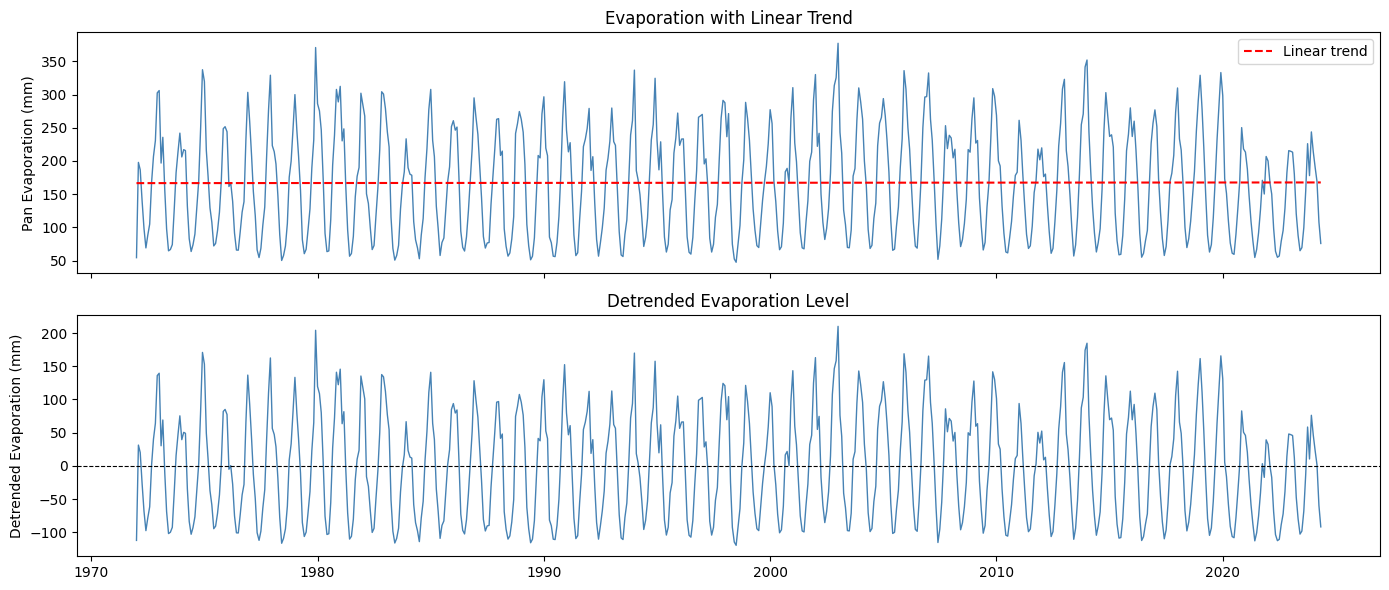

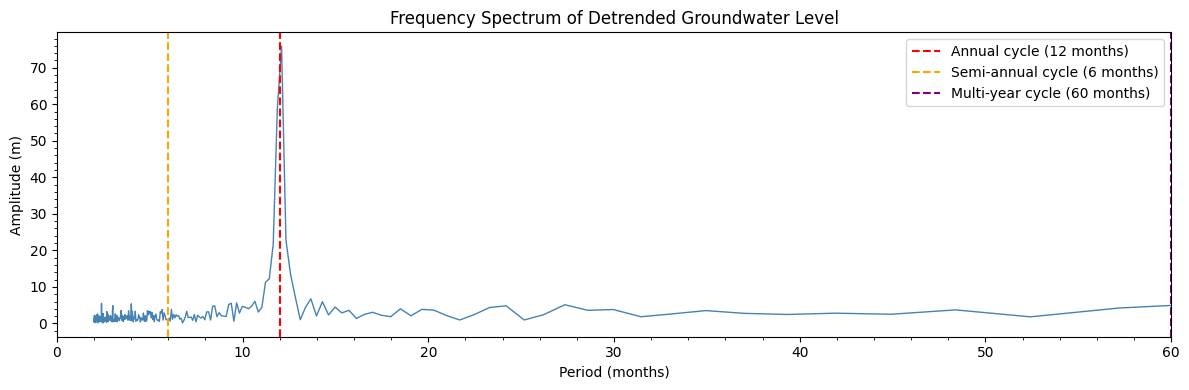

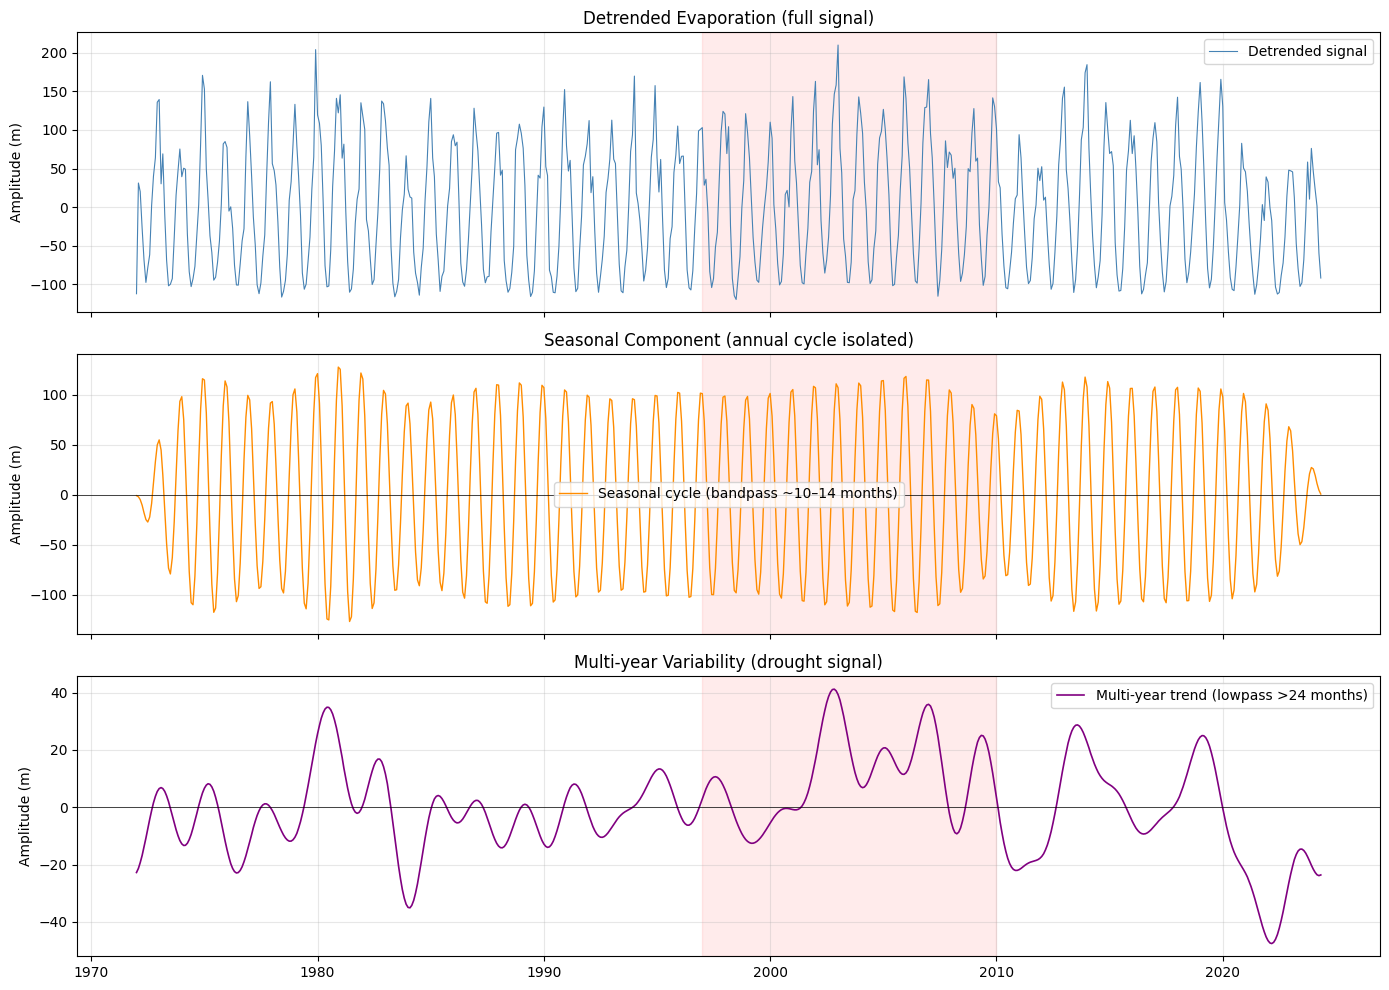

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ── SETUP ──────────────────────────────────────────────────────────────────────
# Convert datetime index to numeric time axis (months since start)
# The FFT functions need a plain numeric array, not datetime objects
time = np.arange(len(df))                  # integer month index: 0, 1, 2, ...
signal = df['evap_pan'].values            # groundwater level as numpy array

# ── STEP 1: DETREND ────────────────────────────────────────────────────────────
# Fit and remove a linear trend (analogous to the Milankovitch example)
pp = np.polyfit(time, signal, 1)           # fit degree-1 polynomial (linear trend)
trend = np.polyval(pp, time)               # evaluate the trend line
detrended = signal - trend                 # remove trend from signal

# Plot raw signal and trend to confirm detrending looks sensible
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(df.index, signal, color='steelblue', linewidth=1)
axes[0].plot(df.index, trend, color='red', linewidth=1.5, linestyle='--', label='Linear trend')
axes[0].set_ylabel('Pan Evaporation (mm)')
axes[0].set_title('Evaporation with Linear Trend')
axes[0].legend()

axes[1].plot(df.index, detrended, color='steelblue', linewidth=1)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_ylabel('Detrended Evaporation (mm)')
axes[1].set_title('Detrended Evaporation Level')
plt.tight_layout()
plt.show()

# ── STEP 2: FREQUENCY SPECTRUM ─────────────────────────────────────────────────
# Uses the same freq_spectrum() function from your class code
freqs, amps = freq_spectrum(time, detrended)

# Convert frequency (cycles/month) to period (months) for labelling
# Ignore the zero-frequency (DC) component at freqs[0]
periods = 1 / freqs[1:]    # period in months
amps_plot = amps[1:]        # matching amplitudes

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(periods, amps_plot, color='steelblue', linewidth=1)

# Mark physically meaningful periods for groundwater
ax.axvline(x=12,  color='red',    linestyle='--', label='Annual cycle (12 months)')
ax.axvline(x=6,   color='orange', linestyle='--', label='Semi-annual cycle (6 months)')
ax.axvline(x=60,  color='purple', linestyle='--', label='Multi-year cycle (60 months)')

ax.set_xlabel('Period (months)')
ax.set_ylabel('Amplitude (m)')
ax.set_title('Frequency Spectrum of Detrended Groundwater Level')
ax.set_xlim([0, 60])      # focus on periods up to ~5 years
ax.legend()
ax.minorticks_on()
plt.tight_layout()
plt.show()

# ── STEP 3: APPLY FILTERS ──────────────────────────────────────────────────────
# Isolate the annual seasonal cycle using a bandpass filter
# Cutoff frequencies in cycles/month: annual = 1/12, allow ± a couple months
cutoff_seasonal = [1/14, 1/10]     # bandpass around the annual cycle

x_filt, y_seasonal = bandpass_filter(time, detrended, cutoff_seasonal)

# Isolate slow multi-year variability (e.g. drought cycles) using a lowpass filter
cutoff_lowpass = 1/24              # only keep cycles longer than 2 years

x_filt, y_lowpass = lowpass_filter(time, detrended, cutoff_lowpass)

# Plot detrended signal with both filtered components overlaid
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, detrended, color='steelblue', linewidth=0.8, label='Detrended signal')
axes[0].set_ylabel('Amplitude (m)')
axes[0].set_title('Detrended Evaporation (full signal)')
axes[0].legend()

axes[1].plot(df.index, y_seasonal, color='darkorange', linewidth=1, label='Seasonal cycle (bandpass ~10–14 months)')
axes[1].set_ylabel('Amplitude (m)')
axes[1].set_title('Seasonal Component (annual cycle isolated)')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].legend()

axes[2].plot(df.index, y_lowpass, color='purple', linewidth=1.2, label='Multi-year trend (lowpass >24 months)')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_ylabel('Amplitude (m)')
axes[2].set_title('Multi-year Variability (drought signal)')
axes[2].legend()

# Shade Millennium Drought on all panels
for ax in axes:
    ax.axvspan(pd.Timestamp('1997-01-01'), pd.Timestamp('2009-12-31'),
               alpha=0.08, color='red', label='Millennium Drought')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Cross Correlation Determination
Determine cross correlation between rainfall and groundwater - what is the lag?

Rainfall

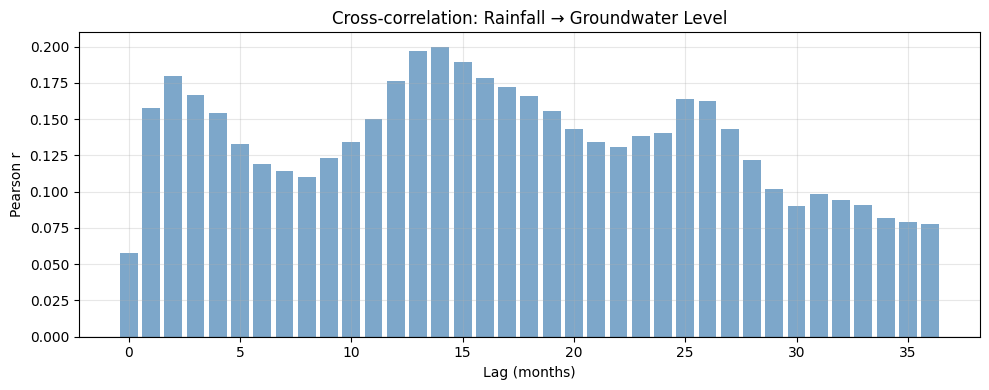

Strongest correlation at lag = 14.0 months, r = 0.200, p = 0.0000


In [49]:
from scipy import stats
import numpy as np

# Cross-correlation: how well does rainfall at time t-lag
# predict groundwater at time t?
max_lag = 36  # test up to 24 months lag

lags = range(0, max_lag + 1)
correlations = []

gw = df['RSWL_mAHD'].dropna()
rain = df['daily_rain'].dropna()

# Align on common index first
aligned = df[['RSWL_mAHD', 'daily_rain']].dropna()

for lag in lags:
    if lag == 0:
        r, p = stats.pearsonr(aligned['daily_rain'], aligned['RSWL_mAHD'])
    else:
        r, p = stats.pearsonr(
            aligned['daily_rain'].iloc[:-lag],
            aligned['RSWL_mAHD'].iloc[lag:]
        )
    correlations.append((lag, r, p))

lag_df = pd.DataFrame(correlations, columns=['lag_months', 'r', 'p_value'])

# Plot the cross-correlation
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lag_df['lag_months'], lag_df['r'], color='steelblue', alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Pearson r')
ax.set_title('Cross-correlation: Rainfall → Groundwater Level')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_lag_rain = lag_df.loc[lag_df['r'].idxmax()]

best_lag_rain_months = int(best_lag_rain['lag_months'])

print(f"Strongest correlation at lag = {best_lag_rain['lag_months']} months, r = {best_lag_rain['r']:.3f}, p = {best_lag_rain['p_value']:.4f}")

Evaporation

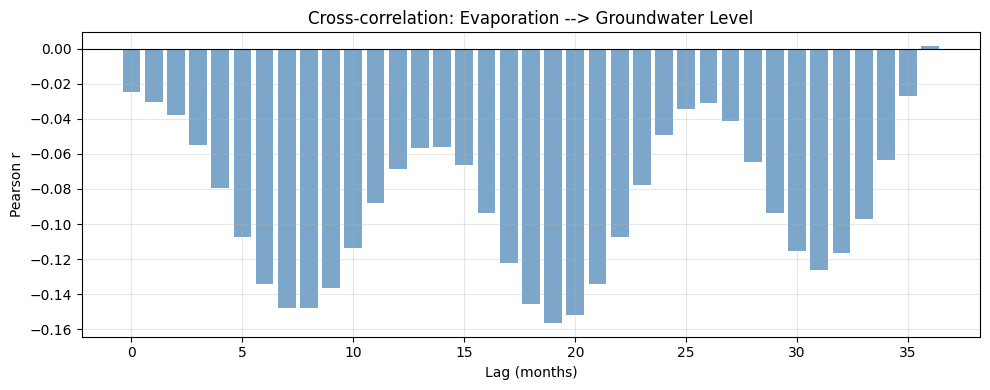

Strongest correlation at lag = 19.0 months, r = -0.156, p = 0.0001


In [46]:
# Cross-correlation: how well does evaporation at time t-lag
# predict groundwater at time t?
max_lag = 36  # test up to 24 months lag

lags = range(0, max_lag + 1)
correlations = []

gw = df['RSWL_mAHD'].dropna()
rain = df['evap_pan'].dropna()

# Align on common index first
aligned = df[['RSWL_mAHD', 'evap_pan']].dropna()

for lag in lags:
    if lag == 0:
        r, p = stats.pearsonr(aligned['evap_pan'], aligned['RSWL_mAHD'])
    else:
        r, p = stats.pearsonr(
            aligned['evap_pan'].iloc[:-lag],
            aligned['RSWL_mAHD'].iloc[lag:]
        )
    correlations.append((lag, r, p))

lag_df = pd.DataFrame(correlations, columns=['lag_months', 'r', 'p_value'])

# Plot the cross-correlation
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lag_df['lag_months'], lag_df['r'], color='steelblue', alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Pearson r')
ax.set_title('Cross-correlation: Evaporation --> Groundwater Level')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_lag_evap = lag_df.loc[lag_df['r'].abs().idxmax()]

best_lag_evap_months = int(best_lag_evap['lag_months'])

print(f"Strongest correlation at lag = {best_lag_evap['lag_months']} months, r = {best_lag_evap['r']:.3f}, p = {best_lag_evap['p_value']:.4f}")

Temperature

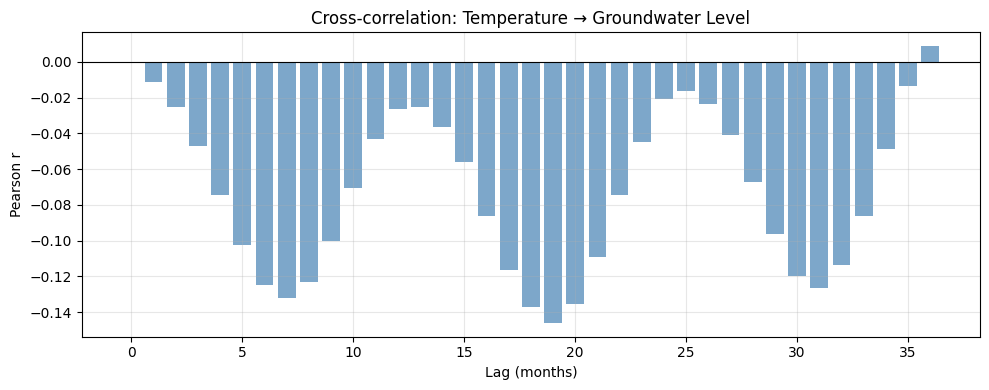

Strongest correlation at lag = 19 months, r = -0.146, p = 0.0003


In [48]:
# Cross-correlation: how well does temperature at time t-lag
# predict groundwater at time t?
max_lag = 36  # test up to 24 months lag

lags = range(0, max_lag + 1)
correlations = []

gw = df['RSWL_mAHD'].dropna()
rain = df['max_temp'].dropna()

# Align on common index first
aligned = df[['RSWL_mAHD', 'max_temp']].dropna()

for lag in lags:
    if lag == 0:
        r, p = stats.pearsonr(aligned['max_temp'], aligned['RSWL_mAHD'])
    else:
        r, p = stats.pearsonr(
            aligned['max_temp'].iloc[:-lag],
            aligned['RSWL_mAHD'].iloc[lag:]
        )
    correlations.append((lag, r, p))

lag_df = pd.DataFrame(correlations, columns=['lag_months', 'r', 'p_value'])

# Plot the cross-correlation
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lag_df['lag_months'], lag_df['r'], color='steelblue', alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Pearson r')
ax.set_title('Cross-correlation: Temperature → Groundwater Level')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_lag_temp = lag_df.loc[lag_df['r'].abs().idxmax()]

best_lag_temp_months = int(best_lag_temp['lag_months'])

print(f"Strongest correlation at lag = {best_lag_temp_months} months, "
      f"r = {best_lag_temp['r']:.3f}, "
      f"p = {best_lag_temp['p_value']:.4f}")

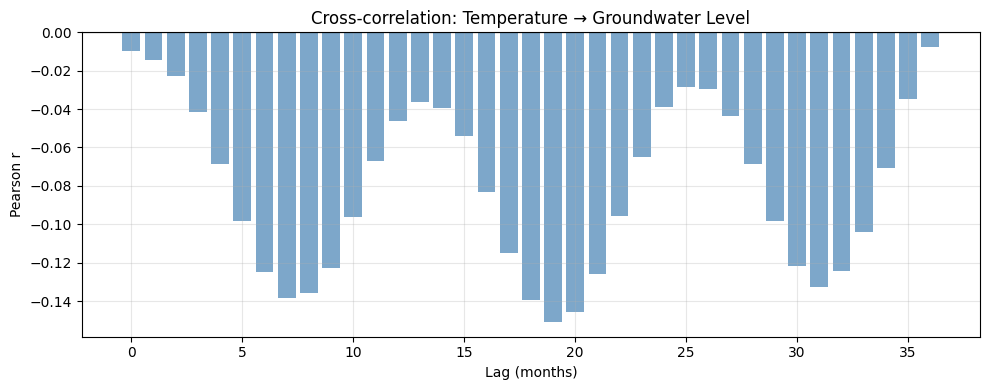

Strongest correlation at lag = 19.0 months, r = -0.156, p = 0.0001


In [51]:
# Cross-correlation: how well does temperature at time t-lag
# predict groundwater at time t?
max_lag = 36  # test up to 24 months lag

lags = range(0, max_lag + 1)
correlations = []

gw = df['RSWL_mAHD'].dropna()
rain = df['et_short_crop'].dropna()

# Align on common index first
aligned = df[['RSWL_mAHD', 'et_short_crop']].dropna()

for lag in lags:
    if lag == 0:
        r, p = stats.pearsonr(aligned['et_short_crop'], aligned['RSWL_mAHD'])
    else:
        r, p = stats.pearsonr(
            aligned['et_short_crop'].iloc[:-lag],
            aligned['RSWL_mAHD'].iloc[lag:]
        )
    correlations.append((lag, r, p))

lag_df = pd.DataFrame(correlations, columns=['lag_months', 'r', 'p_value'])

# Plot the cross-correlation
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lag_df['lag_months'], lag_df['r'], color='steelblue', alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Pearson r')
ax.set_title('Cross-correlation: Temperature → Groundwater Level')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_lag_et = lag_df.loc[lag_df['r'].abs().idxmax()]
best_lag_et_months = int(best_lag_et['lag_months'])

print(f"Strongest correlation at lag = {best_lag_temp['lag_months']} months, r = {best_lag['r']:.3f}, p = {best_lag['p_value']:.4f}")

###Extract optimal lag and build lagged dataset

In [52]:
print(f"Optimal lag — Rainfall:            {best_lag_rain_months} months")
print(f"Optimal lag — Evapotranspiration:  {best_lag_evap_months} months")
print(f"Optimal lag — Max Temperature:     {best_lag_temp_months} months")
print(f"Optimal lag — Max Temperature:     {best_lag_et_months} months")

Optimal lag — Rainfall:            14 months
Optimal lag — Evapotranspiration:  19 months
Optimal lag — Max Temperature:     19 months
Optimal lag — Max Temperature:     19 months


In [91]:
df_lagged = pd.DataFrame(index=df.index)

df_lagged['RSWL_mAHD'] = df['RSWL_mAHD']

# Shift each predictor back by its optimal lag:
# .shift(n) moves values forward n rows, so row t gets the value from t-n
# which means groundwater at t is paired with rainfall at t - lag (correct direction)
df_lagged["rainfall_lagged"] = df['daily_rain'].shift(best_lag_rain_months)
df_lagged['evap_lagged']       = df['evap_pan'].shift(best_lag_evap_months)
df_lagged['temp_lagged']     = df['max_temp'].shift(best_lag_temp_months)
df_lagged['et_lagged']     = df['et_short_crop'].shift(best_lag_et_months)


# Drop rows where any lagged column is NaN
# (the first max_lag rows will be NaN due to shifting)
df_lagged = df_lagged.dropna()

print(f"\nLagged dataset shape: {df_lagged.shape}")
print(f"Date range: {df_lagged.index.min()} to {df_lagged.index.max()}")
print(df_lagged.head())


Lagged dataset shape: (610, 5)
Date range: 1973-08-01 00:00:00 to 2024-05-01 00:00:00
            RSWL_mAHD  rainfall_lagged  evap_lagged  temp_lagged  et_lagged
Date                                                                       
1973-08-01     186.89             24.4         54.3    30.962500       47.5
1973-09-01     187.22              1.6        197.8    31.268966      165.3
1973-10-01     187.18             43.8        186.7    31.448387      162.4
1973-11-01     187.16             21.6        139.2    26.403333      110.7
1973-12-01     187.02             68.1         98.4    22.900000       79.7


#Analysis - Regression Correlation

#####Install bambi

In [54]:
!pip install bambi #system command to install bambi package

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.8/237.8 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.9/179.9 kB 14.7 MB/s eta 0:00:00
  Attempting uninstall: pytensor
    Found existing installation: pytensor 2.38.3
    Uninstalling pytensor-2.38.3:
      Successfully uninstalled pytensor-2.38.3
  Attempting uninstall: arviz
    Found existing installation: arviz 0.22.0
    Uninstalling arviz-0.22.0:
      Successfully uninstalled arviz-0.22.0
  Attempting uninstall: pymc
    Found existing in

In [73]:
import bambi as bmb #for automated Bayesian regression
import arviz as az #for analysis of Bayesian models
import pandas as pd #bambi requires us to work with pandas dataframes

###Single Regression (Rainfall)

Sample correlation r = 0.20
Sample correlation R^2 = 0.04


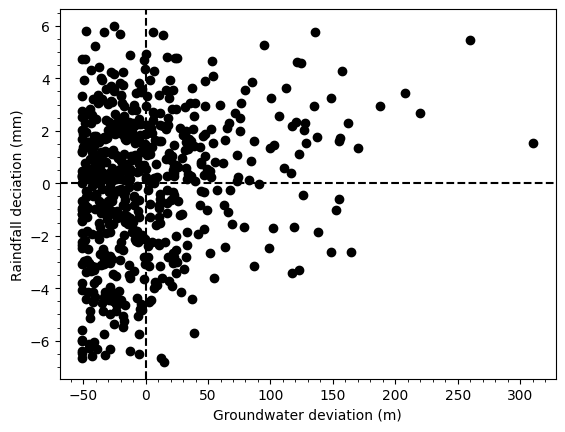

In [89]:
# Extract data for regression
groundwater_level = df_lagged['RSWL_mAHD']
rainfall_lagged = df_lagged['rainfall_lagged']


y = groundwater_level - np.mean(groundwater_level) #deviation in the x variable
x = rainfall_lagged - np.mean(rainfall_lagged) #deviation in the y variable
plt.plot(x,y,'ok') #plot the deviations
plt.gca().axvline(x=0, color = 'k', linestyle = '--') #add a vertical line at x=0
plt.gca().axhline(y=0, color = 'k', linestyle = '--') #add a horizontal line at y=0
plt.xlabel('Groundwater deviation (m)') #label the x-axis
plt.ylabel('Raindfall deciation (mm)') #label the y-axis
plt.minorticks_on() #include minor ticks

num = np.sum(x*y) #find the numerator
den = np.sqrt(np.sum(x**2)) * np.sqrt(np.sum(y**2)) #find the denominator
r = num/den #obtain r
print('Sample correlation r = {:.2f}'.format(r)) #print result to 2 d.p.
r2 = r**2
print('Sample correlation R^2 = {:.2f}'.format(r2)) #print result to 2 d.p.

Scale the x values

In [81]:
data = pd.DataFrame({"y": rainfall_lagged}) #define the y-variable
data["x_scaled"] = (groundwater_level-np.mean(groundwater_level)) / np.std(groundwater_level) #scale the x values to have a mean of 0 and stdev of 1
data["x2_scaled"] = data["x_scaled"] ** 2 #used for quadratic regression
data["x3_scaled"] = data["x_scaled"] ** 3 #used for cubic regression
data["x4_scaled"] = data["x_scaled"] ** 4 #used for quartic regression

In [82]:
# Fit a straight-line model (first-order polynomial)
model_linear = bmb.Model("y ~ x_scaled", data)
idata_linear = model_linear.fit(idata_kwargs={"log_likelihood": True}, progressbar=False) # records logarithm of likelihood

# Fit a quadratic model (second-order polynomial)
model_quad = bmb.Model("y ~ x_scaled + x2_scaled", data)
idata_quad = model_quad.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

# Fit a cubic model (third-order polynomial)
model_cubic = bmb.Model("y ~ x_scaled + x2_scaled + x3_scaled", data)
idata_cubic= model_cubic.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

# Fit a quartic model (fourth-order polynomial)
model_quart = bmb.Model("y ~ x_scaled + x2_scaled + x3_scaled + x4_scaled", data)
idata_quart = model_quart.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  ret

In [66]:
# Compare models
comparison = az.compare({
    "linear": idata_linear,
    "quadratic": idata_quad,
    "cubic": idata_cubic,
    "quartic": idata_quart
})
print(comparison) #print the result

           rank    elpd    p  elpd_diff  weight    se   dse  warning
linear        0 -3250.0  5.2        0.0     1.0  32.0  0.00    False
quadratic     1 -3250.0  6.8       -1.4     0.0  32.0  0.29    False
cubic         2 -3260.0  7.8       -2.0     0.0  32.0  1.00    False
quartic       3 -3260.0  9.0       -3.0     0.0  32.0  1.30    False


Text(0, 0.5, 'Rainfall')

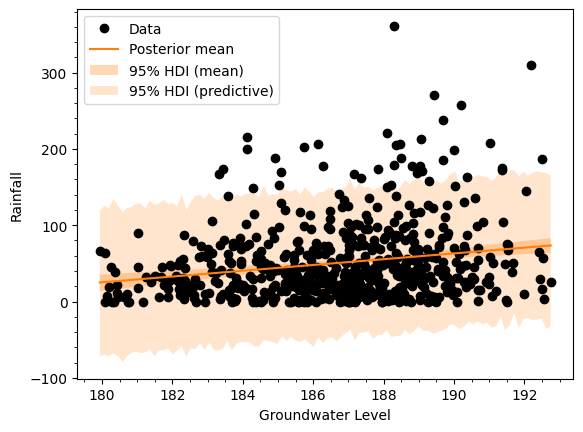

In [85]:
x_range = np.linspace(groundwater_level.min(), groundwater_level.max(), 100) # Predict across a range of distances values from 0 to 40
x_range_scaled = (x_range-np.mean(groundwater_level)) / np.std(groundwater_level) #we need to apply the same scaling as above

new_data = pd.DataFrame({"x_scaled": x_range_scaled}) #dataframe with the new x-values
model_linear.predict(idata_linear, data=new_data, kind='response_params') #predict the distribution of regression lines at each x-value
model_linear.predict(idata_linear, data=new_data, kind='response') #predict the distribution of gravel size at each x-value

# Make random draws from the posterior of the regression lines
y_mean_draws = idata_linear.posterior["mu"].values

# Reshape to (total_draws, x_points)
y_mean_draws = y_mean_draws.reshape(-1, len(x_range))

# Make random draws from the posterior of the gravel size
y_pps_draws = idata_linear.posterior_predictive["y"].values

# Reshape to (total_draws, x_points)
y_pps_draws = y_pps_draws.reshape(-1, len(x_range))

# Compute mean and HDI of the posterior predictive distribution
#posterior_mean = y_pps_draws.mean(axis=0)
posterior_mean = y_mean_draws.mean(axis=0)
hdi_mean = az.hdi(
    y_mean_draws,
    prob=0.95, axis=0)
hdi_pps = az.hdi(
    y_pps_draws,
    prob=0.95, axis=0)

# Plot both posterior for regression lines and the observations
plt.plot(groundwater_level, rainfall_lagged, 'ok', label="Data")
plt.plot(x_range, posterior_mean, color="C1", label="Posterior mean")
plt.fill_between(
    x_range,
    hdi_mean[:, 0],
    hdi_mean[:, 1],
    alpha=0.3,
    color="C1",
    label="95% HDI (mean)",
    edgecolor = None
)

plt.fill_between(
    x_range,
    hdi_pps[:, 0],
    hdi_pps[:, 1],
    alpha=0.2,
    color="C1",
    label="95% HDI (predictive)",
    edgecolor = None
)

plt.legend()
plt.minorticks_on()
plt.xlabel('Groundwater Level')
plt.ylabel('Rainfall')

### Multi Regression

In [96]:
groundwater_level = df_lagged['RSWL_mAHD']
rainfall_lagged = df_lagged['rainfall_lagged']
temp_lagged = df_lagged['temp_lagged']
evap_lagged = df_lagged['evap_lagged']
et_lagged = df_lagged['et_lagged']

# Response variable (groundwater)
data = pd.DataFrame({
    "y": groundwater_level
})

# Standardised predictors
data["rain_scaled"] = (
    rainfall_lagged - np.mean(rainfall_lagged)
) / np.std(rainfall_lagged)

data["temp_scaled"] = (
    temp_lagged - np.mean(temp_lagged)
) / np.std(temp_lagged)

data["et_scaled"] = (
    et_lagged - np.mean(et_lagged)
) / np.std(et_lagged)

data["evap_scaled"] = (
    evap_lagged - np.mean(evap_lagged)
) / np.std(evap_lagged)

In [97]:
## Correlation Matrix
corr = data[[
    "rain_scaled",
    "temp_scaled",
    "et_scaled",
    "evap_scaled"
]].corr()

print(corr)

             rain_scaled  temp_scaled  et_scaled  evap_scaled
rain_scaled     1.000000    -0.221900  -0.189830    -0.187518
temp_scaled    -0.221900     1.000000   0.955880     0.942587
et_scaled      -0.189830     0.955880   1.000000     0.986231
evap_scaled    -0.187518     0.942587   0.986231     1.000000


Interpretation:

|r| < 0.5 → weak/moderate correlation

0.5–0.7 → notable correlation

0.7 → strong multicollinearity concern
- ET and temperature strongly correlated
- Pan evaporation and ET strongly correlated
---

Multiple Regression Model
- direct extension of linear models discussed in class

In [98]:
model_multi = bmb.Model(
    "y ~ rain_scaled + temp_scaled + et_scaled + evap_scaled",
    data
)

idata_multi = model_multi.fit(
    idata_kwargs={"log_likelihood": True},
    progressbar=False
)

/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(


In [99]:
# Extract coefficients
summary = az.summary(
    idata_multi,
    var_names=[
        "rain_scaled",
        "temp_scaled",
        "et_scaled",
        "evap_scaled"
    ]
)

print(summary)

              mean     sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat  \
rain_scaled   0.49  0.112     0.31     0.67      2192      1353  1.00   
temp_scaled   0.18   0.36    -0.42     0.73      1749      1326  1.00   
et_scaled     0.25   0.73    -0.91      1.4      1298      1389  1.00   
evap_scaled  -0.74   0.64     -1.8     0.28      1529      1392  1.00   

            mcse_mean mcse_sd  
rain_scaled    0.0024  0.0017  
temp_scaled    0.0087  0.0063  
et_scaled        0.02   0.014  
evap_scaled     0.016   0.011  


Interpretation
- these coefficients are not correlation (they are partial regression coefficients ie. the independent effects after controlling for other variables)
- better than simple R values
- measures independent contribution after accounting for overlap with other predictors THEREFORE more defensible for this groundwater case

In [101]:
# Actual correlation variables
variables = {
    "Rainfall": rainfall_lagged,
    "Temperature": temp_lagged,
    "ET": et_lagged,
    "Pan evaporation": evap_lagged
}

for name, var in variables.items():

    x = groundwater_level - np.mean(groundwater_level)
    y = var - np.mean(var)

    r = np.sum(x*y) / (
        np.sqrt(np.sum(x**2)) *
        np.sqrt(np.sum(y**2))
    )

    print(f"{name}:")
    print(f"r = {r:.2f}")
    print(f"R² = {r**2:.2f}")
    print()

Rainfall:
r = 0.20
R² = 0.04

Temperature:
r = -0.15
R² = 0.02

ET:
r = -0.15
R² = 0.02

Pan evaporation:
r = -0.16
R² = 0.02



Interpretation
- measures total association (including shared climatic effects)

####Visualise Regression

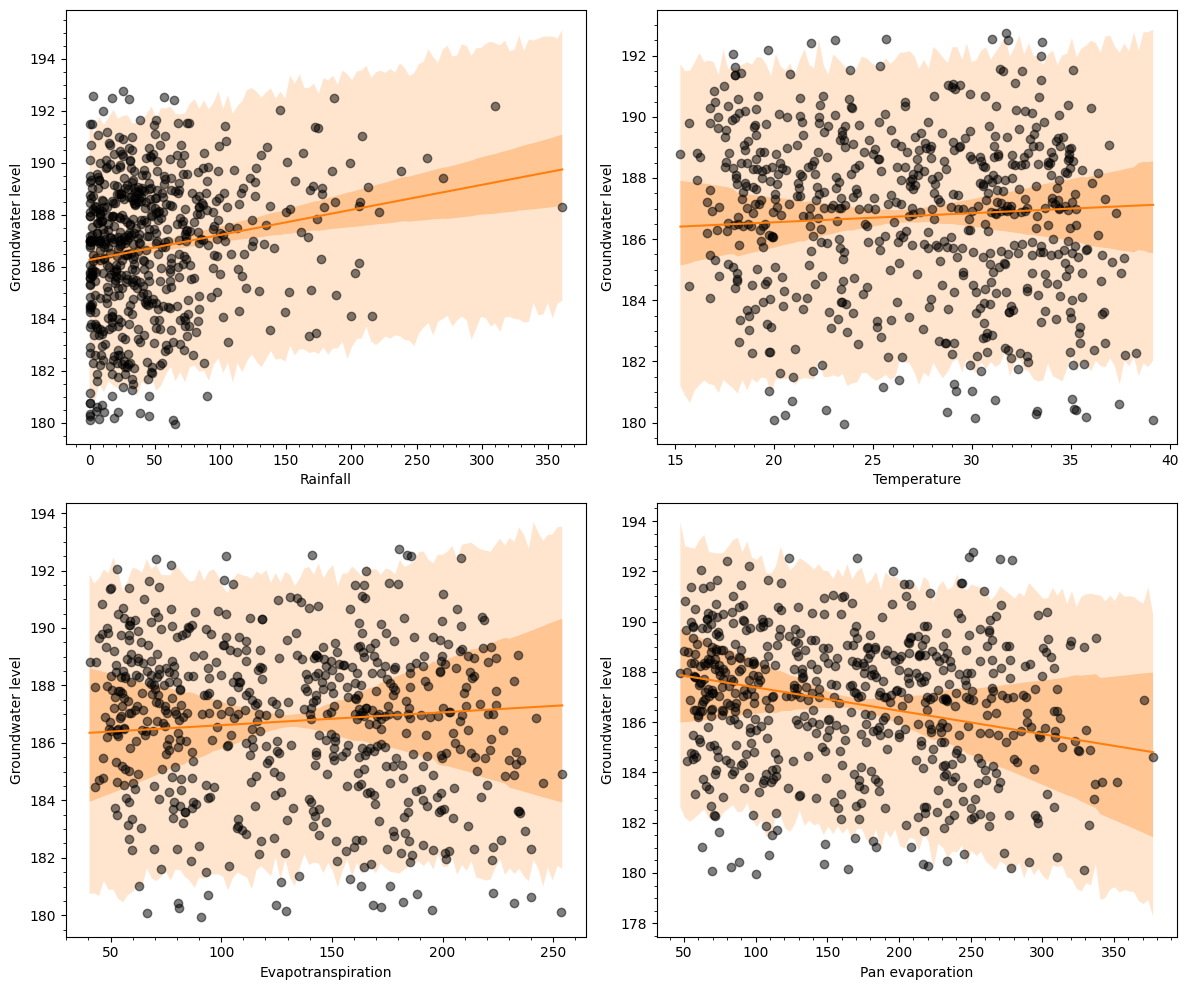

In [102]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

predictors = [
    ("rain_scaled", rainfall_lagged, "Rainfall"),
    ("temp_scaled", temp_lagged, "Temperature"),
    ("et_scaled", et_lagged, "Evapotranspiration"),
    ("evap_scaled", evap_lagged, "Pan evaporation")
]

axes = axes.flatten()

for ax, (var_name, raw_data, label) in zip(axes, predictors):

    # Create prediction range for this variable
    x_range = np.linspace(raw_data.min(), raw_data.max(), 100)

    # Scale using same transformation as model fitting
    x_scaled = (
        x_range - np.mean(raw_data)
    ) / np.std(raw_data)

    # Hold all predictors at mean = 0
    new_data = pd.DataFrame({
        "rain_scaled": np.zeros(len(x_range)),
        "temp_scaled": np.zeros(len(x_range)),
        "et_scaled": np.zeros(len(x_range)),
        "evap_scaled": np.zeros(len(x_range))
    })

    # Vary only the predictor of interest
    new_data[var_name] = x_scaled

    # Generate predictions
    model_multi.predict(
        idata_multi,
        data=new_data,
        kind='response_params'
    )

    model_multi.predict(
        idata_multi,
        data=new_data,
        kind='response'
    )

    # Posterior draws
    y_mean_draws = idata_multi.posterior["mu"].values
    y_mean_draws = y_mean_draws.reshape(-1, len(x_range))

    y_pps_draws = idata_multi.posterior_predictive["y"].values
    y_pps_draws = y_pps_draws.reshape(-1, len(x_range))

    # Mean + HDI
    posterior_mean = y_mean_draws.mean(axis=0)

    hdi_mean = az.hdi(
        y_mean_draws,
        prob=0.95,
        axis=0
    )

    hdi_pps = az.hdi(
        y_pps_draws,
        prob=0.95,
        axis=0
    )

    # Plot observations
    ax.plot(raw_data, groundwater_level, 'ok', alpha=0.5)

    # Posterior mean
    ax.plot(
        x_range,
        posterior_mean,
        color="C1",
        label="Posterior mean"
    )

    # HDI mean
    ax.fill_between(
        x_range,
        hdi_mean[:, 0],
        hdi_mean[:, 1],
        alpha=0.3,
        color="C1",
        edgecolor=None
    )

    # Predictive HDI
    ax.fill_between(
        x_range,
        hdi_pps[:, 0],
        hdi_pps[:, 1],
        alpha=0.2,
        color="C1",
        edgecolor=None
    )

    ax.set_xlabel(label)
    ax.set_ylabel("Groundwater level")
    ax.minorticks_on()

plt.tight_layout()
plt.show()

Partial Regression Plots
- each pannel shows the relationship between groundwater and this variable, after controlling for all other climatic variables
- more powerful than seperate bivariate regressions

### Overall Interpretation of Muli-variable Regression:

**Extracter Coefficients**

Rainfal = +0.49
Temperature = +0.18
ET = +0.25
Pan evaporation = -0.74
- predictors have been standardaised so they represent the groundwater response (in m) to one standard deviation increase in the predictor

Randfall
- clearest signal = strongest independent recharge control
- uncertainly interval doesn't overlap zero much

Temperature
- weak and highly uncertain
- interval spans negative and positive values
- contributes little alone (reflects multicollinearity)

Evapotranspiration
- surprising result as ET usually reduces groundwater
- likely because ET is strongly correlated with rainfall seasonality and this model struggles to seperate it
- the extremely wide uncertainty interval confirms this instability

Pan Evaporation
- strongest negative relationship = dominant groundwater loss mechanism
- higher evaporative demans reduces groundwater use
- uncertainty is large however the negative trend is meaningful

**Simple Correlations**
- fairly weak
- no simple climatic variable strongly explains groundwater independently

**Overall**

Simple correlation: shared association between two variables
- overall climatic association

Multiple regression coefficient: indepdendent effect of predictor after controlling for other factors
- isolate independent groundwater contribution
- however in the cases of temp and ET multicollinearity limits interpretation of individual climatic predictors

**Application to model**
Muli-regression coefficients are more appropriate for weighting factors in the groundwater storage model

#Model Creation

# Reflection

While thinking about potential applications I considered what prior knowledge could help me contextualise a question. I noticed over the course of the group projects that the more difficult ones coincided with an overly complet problem/topic that would have required siginificant prior understanding to better understand would could be done with the data. Hence I reflected on a water science course I did in the summer and considered the concept of water modelling, and more specifically groundwater modelling. Groundwater reserves are of significant important to Australia as out agricultural systems, etc.

**Break down the roles**
Git hub and colab creation: created new repository, created a colab notebook seperately, commited to repository by adding a new branch

**Engagement with content**
- engaged more meaningfully in the course when I started doing hand written notes, helped me fully process the content
- had difficulty fully comprehending/committing to memory techniques and such from the notebook demonstrations - realised this was not the essential part of scientific coding

Identify what worked well, what didn't work so well, what hurdles encountered and how did you pivot

Progress Check (week 11)
- orignally randomly selected a bore site in the Namoi region (that had continuous data from 1970s) however I later found the Lower Namoi hydrogeological conceptual model report which provided context on the geology of the region.
- from this report is selected a new borehole GW030170 because it is described as showing flood and climatic variations...
- note this is not cherry picking, simply gives me the chance to analyse something wiht  

Progress Check (cross correlation)
- realised that it wouldn't be logical to directly compare
- used AI to understand how cross correlation could be coded
- applied to all models and checked with sources online for consistency
- learning opportunity, allowing me to actually play with the data
- had to make new datasets to store this lagged data

Progress Check (regression modelling section)
- conducted single variable regression modelling and realised this could be clouded for this data due to the intervariability of climate
- extended the case to multi-variable (used a bit of AI to check how to do this with bambi) but discovered it's a simple extension just setting more variables (CHECK THIS WASN'T DONE IN CLASS)
- used the extracted coefficients to inform the model